# 2단계 — 보행자 도로망 그래프화 및 인프라 스냅

1단계에서 모은 인프라(병원, 카페 등)를 실제 보행자 도로망 그래프에 붙이는(스냅) 단계다.

이 단계가 왜 필요한지, `network_type="walk"`를 왜 골랐는지, 스냅이 정확히 뭘 하는 작업인지는 `step2_도로망_스냅_설명.md`에 정리했다.

핵심 로직은 `snap_infra_to_network.py`에 있고, 이 노트북은 그 모듈을 불러와 실행하고 결과를 확인하는 역할만 한다.

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.append(str(Path.cwd()))
import collect_infra_places as infra
import snap_infra_to_network as snap

## 도로망 그래프 받기

osmnx가 Overpass API로 대상 bbox(1단계와 동일한 정문 반경 1km)의 보행자 도로망을 받아온다. `network_type="walk"`라서 인도가 따로 태깅 안 된 일반 도로도 포함된다 (설명 문서 3장 참고).

In [2]:
G = snap.fetch_graph()
print(f"그래프: 노드 {len(G.nodes):,}개, 엣지 {len(G.edges):,}개")

snap.DATA_DIR.mkdir(exist_ok=True)
import osmnx as ox
ox.save_graphml(G, snap.GRAPH_PATH)
print(f"저장: {snap.GRAPH_PATH}")

그래프: 노드 576개, 엣지 1,626개
저장: C:\Users\kjyil\Documents\python_study\DartB_TOYPROJECT\data\pedestrian_graph.graphml


## 그래프 모양 확인

숫자만으로는 감이 안 오니, 받아온 도로망을 그림으로 먼저 확인한다.

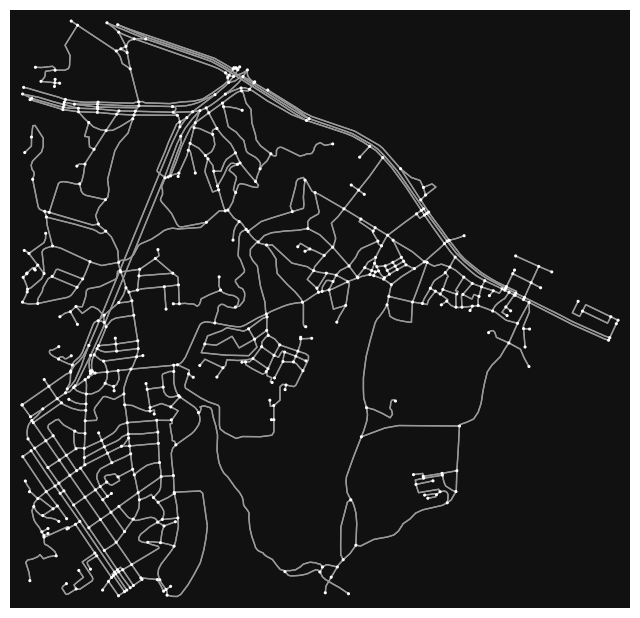

In [3]:
fig, ax = ox.plot_graph(G, node_size=5, figsize=(8, 8))

## 인프라 불러오기

1단계 산출물(`data/kakao_places_infra.jsonl`)을 불러온다.

In [4]:
df = snap.load_infra()
print(f"인프라: {len(df):,}건")

인프라: 770건


## 스냅 실행

각 인프라 좌표에서 가장 가까운 그래프 노드를 찾고, 그 사이 거리(스냅 거리, m)를 함께 구한다 (설명 문서 4장 참고: 거리 계산을 위해 내부적으로 그래프를 평면 좌표계로 투영한다).

In [5]:
df_snapped = snap.snap_infra(df, G)
df_snapped.to_csv(snap.SNAPPED_PATH, index=False, encoding="utf-8-sig")
print(f"저장: {snap.SNAPPED_PATH}")

df_snapped["snap_distance_m"].describe()

저장: C:\Users\kjyil\Documents\python_study\DartB_TOYPROJECT\data\infra_snapped.csv


count    770.000000
mean      27.604598
std       19.856138
min        5.180382
25%       15.029832
50%       21.672689
75%       32.395477
max      150.102703
Name: snap_distance_m, dtype: float64

## 스냅 거리 이상치 점검

스냅 거리가 크다는 건 그 인프라 주변에 그래프가 비어있다는 뜻이다(설명 문서 4장). 어떤 인프라가 이런 경우인지 확인해서, 실제로 문제인지(좌표 오류, 그래프 범위 밖 등) 판단해야 한다.

In [6]:
print(f"스냅 거리 100m 초과: {(df_snapped['snap_distance_m'] > 100).sum()}건")
print(f"스냅 거리 50m 초과: {(df_snapped['snap_distance_m'] > 50).sum()}건")

df_snapped.sort_values("snap_distance_m", ascending=False)[
    ["place_name", "category_group_name", "road_address_name", "snap_distance_m"]
].head(15)

스냅 거리 100m 초과: 13건
스냅 거리 50m 초과: 79건


,place_name,category_group_name,road_address_name,snap_distance_m
743,카페 구앤몽,카페,서울 동작구 서달로 129,150.102703
709,서울형키즈카페 동작구흑석동점,카페,서울 동작구 서달로 129,150.102703
117,CU 중앙대2생활관점,편의점,서울 동작구 흑석로 84,132.329062
93,우리온누리약국,약국,서울 동작구 흑석한강로 27,127.688342
369,카우버거 서울캠퍼스점,음식점,서울 동작구 흑석로 84,120.311495
763,블럭카페 플레고,카페,서울 동작구 흑석한강로 27,114.995711
377,동경카츠,음식점,서울 동작구 흑석로 84,114.934529
51,다시봄의원,병원,서울 동작구 흑석한강로 27,114.865267
123,세븐일레븐 중앙대경영관점,편의점,서울 동작구 흑석로 84,110.834659
700,커피니 중앙대310관점,카페,서울 동작구 흑석로 84,109.875558


실제로 실행해보니 스냅 거리가 큰 상위 항목 상당수가 `서울 동작구 흑석로 84`(중앙대 캠퍼스 건물 주소)나 `흑석한강로 27` 근처에 몰려 있었다. 캠퍼스 내부 통로나 강변 쪽 길이 OSM의 공개 도로망(`network_type="walk"`)에 충분히 태깅돼 있지 않아서, 그 안에 있는 인프라들이 캠퍼스 밖 큰길의 노드로 스냅된 것으로 보인다. 이건 설명 문서 7장에서 미리 짚은 한계가 실제로 나타난 사례이고, 구간 난이도 설계 단계에서 이런 스냅 거리가 큰 구간을 어떻게 다룰지(가중치를 낮추거나 별도 표시) 다시 검토해야 한다.

## 지도로 확인

도로망, 인프라 원래 좌표, 스냅된 노드를 한 지도에 같이 찍어서 스냅이 그럴듯하게 됐는지 눈으로 확인한다. 인프라 좌표와 스냅된 노드를 선으로 이어서, 선이 유난히 긴 곳이 위에서 찾은 이상치와 일치하는지도 본다.

In [7]:
import folium

m = folium.Map(location=[infra.CENTER_LAT, infra.CENTER_LON], zoom_start=15, tiles="cartodbpositron")

# 도로망 엣지
for u, v, data in G.edges(data=True):
    if "geometry" in data:
        coords = [(lat, lon) for lon, lat in data["geometry"].coords]
    else:
        coords = [(G.nodes[u]["y"], G.nodes[u]["x"]), (G.nodes[v]["y"], G.nodes[v]["x"])]
    folium.PolyLine(coords, color="gray", weight=2, opacity=0.6).add_to(m)

# 인프라 원래 좌표 -> 스냅된 노드 연결선 + 점
for _, row in df_snapped.iterrows():
    node = G.nodes[row["snapped_node_id"]]
    color = "red" if row["snap_distance_m"] > 50 else "blue"
    folium.CircleMarker(
        [row["y"], row["x"]], radius=3, color=color, fill=True,
        popup=f"{row['place_name']} (스냅거리 {row['snap_distance_m']:.0f}m)",
    ).add_to(m)
    if row["snap_distance_m"] > 50:
        folium.PolyLine([(row["y"], row["x"]), (node["y"], node["x"])], color="red", weight=1).add_to(m)

folium.Marker(
    [infra.CENTER_LAT, infra.CENTER_LON], popup="중앙대 정문", icon=folium.Icon(color="green"),
).add_to(m)

m

C:\Users\kjyil\AppData\Local\Programs\Python\Python314\Lib\site-packages\folium\raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore
